# Scaling, encoding, and the pipeline that holds them together

This notebook implements handout sections 5 (scaling), 6 (encoding) and 8
(pipelines). It builds the preprocessing that notebook 1 argued for, turns it
into a single `Pipeline`, and — for the scaling half — first shows *why* from
scratch with plain NumPy gradient descent, before reaching for the library.


## 1. Setup

In [1]:
# Everything used here ships with the course image:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, StandardScaler

from churn_data import LOW_CARD_CATEGORICAL, NUMERIC_FEATURES, TARGET, make_churn_data

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)


## 2. Split first, as Lesson 1 insisted

Nothing below is learned before this line runs. `zip_code` is dropped for now —
it returns, deliberately, in notebook 3.


In [2]:
df = make_churn_data(n=2000, seed=RANDOM_STATE)
X = df.drop(columns=[TARGET, "zip_code"])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"train: {len(X_train)}   test: {len(X_test)}")
print(f"baseline (always 'no churn'): {1 - y_train.mean():.3f}")


train: 1500   test: 500
baseline (always 'no churn'): 0.806


## 3. Why scale, from scratch

Handout Section 5.2 derives why unscaled features slow gradient descent down:
the cost surface of a linear model is stretched along the low-variance
direction and squeezed along the high-variance one, so a single learning rate
that is safe for the flat direction is unstable for the steep one.
Standardising every feature to mean 0, variance 1 makes the surface roughly
circular, and a single rate then works well for all of them at once.

To see the effect cleanly, isolate it first on a small controlled example
before touching the messy churn features, where outliers and correlated
columns would blur what is happening. Two features, deliberately built with a
100-to-1 variance ratio, generate a churn-like label; nothing else in the data
is allowed to complicate the picture.


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def logistic_gd(X, y, lr, n_iter=200):
    """Plain-NumPy batch gradient descent on the logistic loss. Returns the loss history."""
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for _ in range(n_iter):
        z = X @ w + b
        p = sigmoid(z)
        eps = 1e-12
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        losses.append(loss)
        if not np.isfinite(loss):
            break
        grad_w = X.T @ (p - y) / n
        grad_b = np.mean(p - y)
        w -= lr * grad_w
        b -= lr * grad_b
    return np.array(losses)


toy_rng = np.random.default_rng(0)
n_toy = 1000
x1 = toy_rng.normal(0, 1, n_toy)     # small variance
x2 = toy_rng.normal(0, 10, n_toy)    # 100x the variance of x1
true_w = np.array([1.5, 0.15])       # chosen so both features matter about equally
logits = true_w[0] * x1 + true_w[1] * x2
y_toy = toy_rng.binomial(1, sigmoid(logits))

X_toy = np.column_stack([x1, x2])
X_toy_scaled = (X_toy - X_toy.mean(axis=0)) / X_toy.std(axis=0)
print(f"feature standard deviations: {X_toy.std(axis=0)}   "
      f"variance ratio: {X_toy.var(axis=0).max() / X_toy.var(axis=0).min():.0f}")


feature standard deviations: [ 0.97675296 10.22713768]   variance ratio: 110


Now find, for each version of the data, roughly the largest learning rate that
still descends smoothly — and see what happens when the *raw* features are
forced to use the rate the *scaled* features tolerate comfortably.


In [4]:
lr_raw, lr_scaled, n_iter = 0.1, 2.0, 200

losses_raw = logistic_gd(X_toy, y_toy, lr=lr_raw, n_iter=n_iter)
losses_scaled = logistic_gd(X_toy_scaled, y_toy, lr=lr_scaled, n_iter=n_iter)
losses_raw_at_scaled_rate = logistic_gd(X_toy, y_toy, lr=lr_scaled, n_iter=n_iter)

print(f"raw,    lr={lr_raw}: loss after {n_iter} steps = {losses_raw[-1]:.4f}")
print(f"scaled, lr={lr_scaled}: loss after {n_iter} steps = {losses_scaled[-1]:.4f}")

# The third run needs describing rather than summarising: quoting its loss at
# step 200 would be quoting one arbitrary point of an oscillation.
bad = losses_raw_at_scaled_rate
print(f"\nraw,    lr={lr_scaled} (the rate the scaled run tolerates):")
print(f"  starts at {bad[0]:.4f}, then swings between {bad.min():.2f} and {bad.max():.2f}")
print(f"  mean over the first 100 steps: {bad[:100].mean():.2f}"
      f"   over the last 100: {bad[100:].mean():.2f}")
print(f"  still finite after {len(bad)} steps, and no closer to settling")

raw,    lr=0.1: loss after 200 steps = 0.4183
scaled, lr=2.0: loss after 200 steps = 0.4155

raw,    lr=2.0 (the rate the scaled run tolerates):
  starts at 0.6931, then swings between 0.69 and 8.29
  mean over the first 100 steps: 3.64   over the last 100: 3.04
  still finite after 200 steps, and no closer to settling


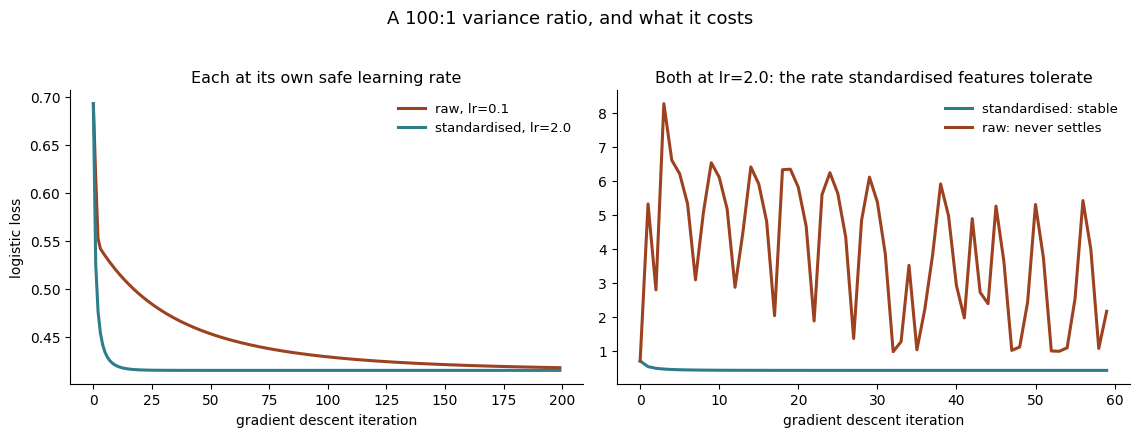

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].plot(losses_raw, lw=2.2, color="#9C4221", label=f"raw, lr={lr_raw}")
axes[0].plot(losses_scaled, lw=2.2, color="#2E7D8A", label=f"standardised, lr={lr_scaled}")
axes[0].set_title("Each at its own safe learning rate", fontsize=11.5)
axes[0].set_xlabel("gradient descent iteration")
axes[0].set_ylabel("logistic loss")
axes[0].legend(frameon=False, fontsize=9.5)
axes[0].spines[["top", "right"]].set_visible(False)

n_show = 60
axes[1].plot(losses_scaled[:n_show], lw=2.2, color="#2E7D8A", label="standardised: stable")
axes[1].plot(losses_raw_at_scaled_rate[:n_show], lw=2.2, color="#9C4221", label="raw: never settles")
axes[1].set_title(f"Both at lr={lr_scaled}: the rate standardised features tolerate", fontsize=11.5)
axes[1].set_xlabel("gradient descent iteration")
axes[1].legend(frameon=False, fontsize=9.5)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("A 100:1 variance ratio, and what it costs", y=1.03, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / "gd_convergence_scaled_vs_unscaled.png", dpi=150, bbox_inches="tight")
plt.show()


Three things happened. Standardised features converge to essentially the same
final loss in a fraction of the iterations, because they tolerate a learning
rate 20 times larger.

And that same larger rate, applied to the *raw* features, does not converge at
all. Be precise about the failure, because "diverges" is the word people reach
for and it is not quite what this is: the loss does not climb steadily to
infinity. It **oscillates without settling**, swinging between roughly 0.7 and
8.3 forever — each step overshoots the steep axis, lands on the far wall, and
overshoots back. Run it for 2000 steps instead of 200 and it is still bouncing
in the same band. That is worse than slow convergence, not better: a slow run
finishes eventually, and this one never does.

One learning rate cannot be both safe and fast when the two axes disagree this
much about scale, and this is precisely handout Section 5.2's conditioning
argument made visible.

Our churn features are a different case, and worth a moment because it is a
trap. Taken as they arrive, `monthly_charges` has about 3.6 times the standard
deviation of `tenure_months` — which looks like a reason to scale. But that
spread is almost entirely the 20 billing errors of notebook 1: clean them out
and the ratio is **0.8**, with `tenure_months` the wider of the two. So this
dataset is not the argument for scaling; a toy built for the purpose is. The
argument for scaling here is that it costs nothing and you cannot count on a
column not being like `x2`.

> **Try this:** change the toy's variance ratio (the `10` in
> `toy_rng.normal(0, 10, n_toy)`) to `3` and to `30`, and rerun. Does the gap
> between `lr_raw` and `lr_scaled` you need to stay stable grow or shrink with
> the ratio? That relationship is exactly the condition number in Section 5.2.

## 4. StandardScaler vs MinMaxScaler

Two standard choices, both **fitted on training data only**:

$$z = \frac{x - \mu}{\sigma} \qquad\qquad x_{\text{minmax}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Reference: [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and
[`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html). Both are new here;
`StandardScaler` you met in Lesson 1.

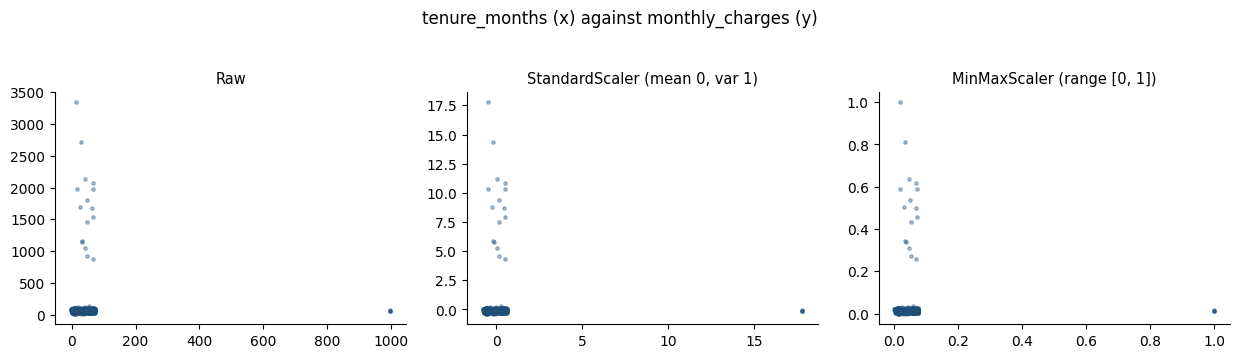

In [6]:
sample = X_train[["tenure_months", "monthly_charges"]].fillna(X_train[["tenure_months", "monthly_charges"]].median())

std_scaled = StandardScaler().fit_transform(sample)
minmax_scaled = MinMaxScaler().fit_transform(sample)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=False)
for ax, data, title in zip(
    axes,
    [sample.to_numpy(), std_scaled, minmax_scaled],
    ["Raw", "StandardScaler (mean 0, var 1)", "MinMaxScaler (range [0, 1])"],
):
    ax.scatter(data[:, 0], data[:, 1], s=6, alpha=0.35, color="#1F4E79")
    ax.set_title(title, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("tenure_months (x) against monthly_charges (y)", y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / "scaling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


`MinMaxScaler` is the more sensitive of the two to outliers: a single extreme
`monthly_charges` billing error stretches the whole 0-1 range, compressing
every ordinary customer into a sliver of it. `StandardScaler` is pulled by
outliers too, through the mean and standard deviation, but far less
dramatically. Neither is a substitute for the outlier handling in notebook 1 —
scaling reshapes a distribution, it does not decide whether a value is wrong.


## 5. Encoding categorical variables, and the dummy variable trap

One-hot encoding turns a $k$-category column into $k$ binary columns. Do this
naively alongside a model that fits an intercept and the design matrix becomes
**rank deficient**: the $k$ dummy columns always sum to a column of ones, which
is exactly the intercept column. Handout Section 6.1 proves it; here we check it
directly with
[`numpy.linalg.matrix_rank`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html),
which returns the number of linearly independent columns.

The encoding itself uses
[`pandas.get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)
rather than scikit-learn's encoder, because here we only want to *look* at the
matrix rather than fit anything: `get_dummies` returns a labelled DataFrame,
which is easier to read. Its `drop_first` argument is the same idea as
`OneHotEncoder(drop="first")`. Inside a pipeline you always want the
scikit-learn version — see the note after the output.

In [7]:
contract_dummies_full = pd.get_dummies(X_train["contract_type"], drop_first=False).astype(float)
contract_dummies_full.insert(0, "intercept", 1.0)

contract_dummies_dropped = pd.get_dummies(X_train["contract_type"], drop_first=True).astype(float)
contract_dummies_dropped.insert(0, "intercept", 1.0)

print("columns with all k dummies + intercept:", contract_dummies_full.shape[1],
      " rank:", np.linalg.matrix_rank(contract_dummies_full.to_numpy()))
print("columns with k-1 dummies + intercept:  ", contract_dummies_dropped.shape[1],
      " rank:", np.linalg.matrix_rank(contract_dummies_dropped.to_numpy()))


columns with all k dummies + intercept: 4  rank: 3
columns with k-1 dummies + intercept:   3  rank: 3


The first matrix has one more column than its rank: exactly the redundancy the
derivation predicts. `sklearn.preprocessing.OneHotEncoder` defaults to keeping
all $k$ columns (useful for models with no intercept, and for tree-based
models later in the course, which do not care about collinearity); pass
`drop="first"` when the downstream model does fit an intercept, as logistic
regression does here.


## 6. `zip_code`, and why it waits

`zip_code` has 493 levels. One-hot encoding it would add 493 sparse columns for
a signal notebook 1's correlation heatmap already suggested is weak. The
natural-looking fix — replace each code with the historical churn rate of
customers who share it — is deferred to notebook 3 on purpose: computed the
obvious way, it leaks.


493 levels across 2000 rows
mean rows per level: 4.1   median: 4   max: 12
share of the matrix that is zero: 0.9980


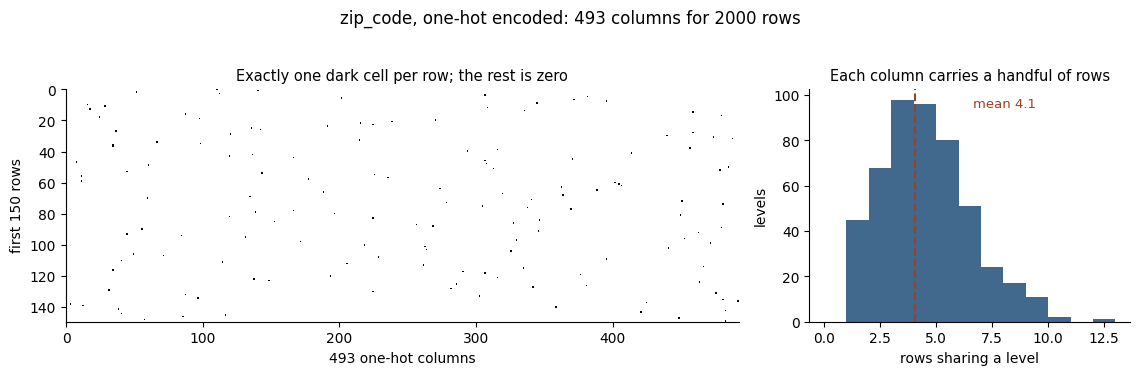

In [8]:
# What one-hot encoding zip_code would actually produce.
zip_dummies = pd.get_dummies(df["zip_code"]).astype(np.uint8)
rows_per_level = zip_dummies.sum(axis=0)

print(f"{zip_dummies.shape[1]} levels across {len(df)} rows")
print(f"mean rows per level: {rows_per_level.mean():.1f}   "
      f"median: {int(rows_per_level.median())}   max: {rows_per_level.max()}")
print(f"share of the matrix that is zero: {1 - zip_dummies.to_numpy().mean():.4f}")

fig, (ax_m, ax_h) = plt.subplots(1, 2, figsize=(11.5, 3.6),
                                 gridspec_kw={"width_ratios": [2.1, 1]})

shown = 150
ax_m.imshow(zip_dummies.to_numpy()[:shown], aspect="auto",
            cmap="binary", interpolation="nearest", vmin=0, vmax=1)
ax_m.set_xlabel(f"{zip_dummies.shape[1]} one-hot columns")
ax_m.set_ylabel(f"first {shown} rows")
ax_m.set_title("Exactly one dark cell per row; the rest is zero", fontsize=10.5)

ax_h.hist(rows_per_level, bins=range(0, int(rows_per_level.max()) + 2),
          color="#1F4E79", alpha=0.85)
ax_h.axvline(rows_per_level.mean(), color="#9C4221", ls="--", lw=1.5)
ax_h.text(rows_per_level.mean() + 2.6, ax_h.get_ylim()[1] * 0.92,
          f"mean {rows_per_level.mean():.1f}", color="#9C4221", fontsize=9.5)
ax_h.set_xlabel("rows sharing a level")
ax_h.set_ylabel("levels")
ax_h.set_title("Each column carries a handful of rows", fontsize=10.5)
for ax in (ax_m, ax_h):
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("zip_code, one-hot encoded: 493 columns for 2000 rows", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "onehot_width.png", dpi=150, bbox_inches="tight")
plt.show()

The left panel is the shape of the problem: a matrix that is almost entirely
zero, one dark cell per row. The right panel is why it matters — a column that
carries four rows on average cannot support a coefficient estimated from those
four rows, which is the curse of dimensionality arriving in a concrete form.

## 7. `ColumnTransformer` + `Pipeline`

Different columns need different treatment: the numeric ones need imputing
then scaling, the low-cardinality categoricals need imputing then one-hot
encoding. `ColumnTransformer` applies a different sub-pipeline to each group of
columns and concatenates the result; wrapped in an outer `Pipeline` with the
classifier, the whole thing is a single object that a `fit` call, and only a
`fit` call, ever learns from.

Both are new in this lesson and worth reading properly, because everything from
here to the end of the course is built out of them:
[`ColumnTransformer`](https://scikit-learn.org/stable/modules/compose.html#columntransformer-for-heterogeneous-data),
[`Pipeline`](https://scikit-learn.org/stable/modules/compose.html#pipeline),
[`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).
The score below uses
[`roc_auc_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html), which Lesson 4
derives — for today read it as "how well does this rank churners above
non-churners", where 0.5 is a coin flip.

In [9]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipe, NUMERIC_FEATURES),
    ("categorical", categorical_pipe, LOW_CARD_CATEGORICAL),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print(f"baseline accuracy: {baseline.score(X_test, y_test):.3f}")
print(f"model accuracy:    {accuracy_score(y_test, pred):.3f}")
print(f"model AUC:         {roc_auc_score(y_test, proba):.3f}   (0.5 = no better than chance)")


baseline accuracy: 0.806
model accuracy:    0.820
model AUC:         0.751   (0.5 = no better than chance)


Accuracy moves only a little over the baseline — expected, since churn here is
imbalanced (roughly 80/20) and accuracy is dominated by the majority class,
exactly as Lesson 1 warned. The area under the receiver operating
characteristic curve (AUC), which is not fooled by the imbalance, shows
the model is finding real signal. Lesson 4 makes both tools precise; for today
the point is structural, not the score: every learned quantity above — the
median used to impute, the mean and variance used to scale, the categories seen
by the encoder — was learned from `X_train` alone, because it never left the
pipeline that was fitted on it.


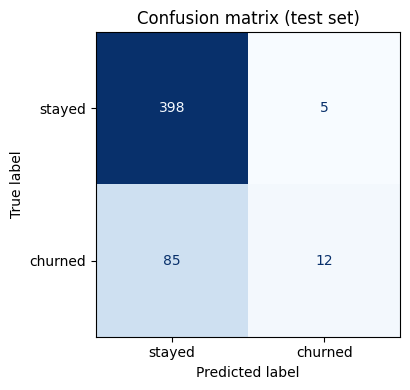

In [10]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=["stayed", "churned"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion matrix (test set)")
fig.tight_layout()
fig.savefig(FIGURES / "churn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature engineering, inside the pipeline

A domain-motivated feature — the charge accumulated relative to how long the
customer has stayed — needs a computation, not just a lookup, but it is still
something that must be built from `X_train` alone in principle (here it needs
no fitted statistic, only arithmetic, so a
[`FunctionTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html)
is enough; Section 7 of the handout gives an example, binning by quantile, that
does learn from data and therefore does need to sit inside a fold).

`FunctionTransformer` wraps a plain Python function as a pipeline step. Because
it learns nothing, its `fit` does nothing and its `transform` just calls the
function — which is exactly why it is safe to apply before the split-sensitive
steps. Note the `.clip(lower=0)` in the function: `tenure_months` still holds
the −3 of notebook 1 at this point, and dividing by `tenure + 1` without the
clip would divide by zero.

In [11]:
def add_charge_per_tenure(frame):
    frame = frame.copy()
    frame["charge_per_tenure"] = frame["monthly_charges"] / (frame["tenure_months"].clip(lower=0) + 1)
    return frame


engineered_numeric = NUMERIC_FEATURES + ["charge_per_tenure"]

preprocess_fe = ColumnTransformer([
    ("numeric", numeric_pipe, engineered_numeric),
    ("categorical", categorical_pipe, LOW_CARD_CATEGORICAL),
])

model_fe = Pipeline([
    ("engineer", FunctionTransformer(add_charge_per_tenure)),
    ("preprocess", preprocess_fe),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
model_fe.fit(X_train, y_train)
proba_fe = model_fe.predict_proba(X_test)[:, 1]
print(f"model AUC without engineered feature: {roc_auc_score(y_test, proba):.3f}")
print(f"model AUC with charge_per_tenure:     {roc_auc_score(y_test, proba_fe):.3f}")


model AUC without engineered feature: 0.751
model AUC with charge_per_tenure:     0.754


A modest gain, if any — which is itself a realistic result. Feature engineering
is a hypothesis, not a guarantee, and it earns its place in the pipeline the
same way any other step does: proposed, tried, measured on data it was not
built from.

## Summary

- Unscaled features distort the geometry gradient descent walks over; the
  from-scratch comparison in Section 3 shows the same code taking far longer
  to reach the same loss on raw features than on standardised ones.
- `StandardScaler` and `MinMaxScaler` both need to be fitted on training data
  only; `MinMaxScaler` is the more outlier-sensitive of the two.
- One-hot encoding all $k$ categories of a variable alongside an intercept
  produces a rank-deficient design matrix — drop one category, or drop the
  intercept.
- High-cardinality categoricals (`zip_code`, with 493 levels) are expensive to
  one-hot encode and, as notebook 3 shows, dangerous to encode by target mean
  without care.
- `ColumnTransformer` inside a `Pipeline` is what makes "fitted on training
  data only" true by construction rather than by discipline, for every step
  from imputation to the final classifier.
